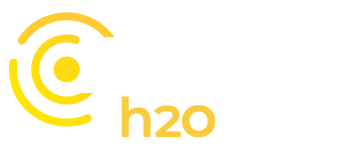<h1 style="display: inline-block; vertical-align: middle;">Quick Start</h1><a class='anchor' id='top'></a>

### <font color='#FFE600'>End-to-end workflow in the h2oGPTe<font>

- [Setup](#Setup)
- [Connect to h2oGPTe](#Connec_to_h2oGPTe)
- [List all available LLMs](#List_all_available_LLMs)
- [Chat with each enabled LLMs](#Chat_with_each_enabled_LLMs)
   - [Chat with vision model](#Chat_with_vision_model)
- [Chat within a Collection](#Chat_within_a_Collection)
   - [Create a Collection](#Create_a_Collection)
   - [Crawl a_website](#Crawl_a_website)
   - [Chat with website data](#Chat_with_website_data)
   - [Add a pdf to Collection](#Add_a_pdf_to_Colection)
   - [Summarize this pdf](#Summarize_this_pdf)
- [Agents](#Agents)
- [Clean up](#Clean_Up)

### <font color='#FFE600'>Setup<font><a class='anchor' id='setup'></a> [↑](#top)

In [1]:
import os
import sys
import requests
import h2ogpte
import importlib
from tabulate import tabulate
from IPython.display import display, HTML
import h2o_discovery
from h2ogpte import H2OGPTE
import h2o_authn

In [2]:
discovery = h2o_discovery.discover()
discovery.services["h2ogpte"].uri

'http://h2ogpte-mux.h2ogpte.svc.cluster.local:8888'

In [3]:
h2ogpte.__version__

'1.5.24'

In [4]:
discovery.services["h2ogpte"].version

'1.6.0'

#### in case h2ogpte python client version is not matching h2oGPTe API server

In [8]:
! pip install h2ogpte=={discovery.services["h2ogpte"].version}
# or 
# ! pip install https://s3.us-east-1.amazonaws.com/artifacts.h2o.ai/snapshots/h2ogpte/py-client/h2ogpte-1.6.0.dev39-py3-none-any.whl
# then reload the h2ogpte library
importlib.reload(h2ogpte)

Defaulting to user installation because normal site-packages is not writeable
  Attempting uninstall: h2ogpte
    Found existing installation: h2ogpte 1.6.0.dev39
    Uninstalling h2ogpte-1.6.0.dev39:
      Successfully uninstalled h2ogpte-1.6.0.dev39

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


<module 'h2ogpte' from '/home/jovyan/.local/lib/python3.11/site-packages/h2ogpte/__init__.py'>

In [9]:
h2ogpte.__version__

'1.6.0'

In [10]:
token_provider = h2o_authn.TokenProvider(
    refresh_token=os.getenv("H2O_CLOUD_CLIENT_PLATFORM_TOKEN"),
    issuer_url=discovery.environment.issuer_url,
    client_id=discovery.clients["platform"].oauth2_client_id,
)

### <font color='#FFE600'>Connect to h2oGPTe<font><a class='anchor' id='setup'></a> [↑](#top)

In [11]:
h2ogpte = H2OGPTE(address=discovery.services["h2ogpte"].uri, token_provider=token_provider)

### <font color='#FFE600'>List_all_available_LLMs<font><a class='anchor' id='setup'></a> [↑](#top)

In [12]:
table = [[key, value] for key, value in h2ogpte.get_llm_and_auto_vision_llm_names().items()]
print(tabulate(table, headers=["LLM", "Vision model"], tablefmt="pretty"))

+------------------------------------------------+------------------------------------------------+
|                      LLM                       |                  Vision model                  |
+------------------------------------------------+------------------------------------------------+
|     meta-llama/Meta-Llama-3.1-8B-Instruct      |           mistralai/Pixtral-12B-2409           |
|           h2oai/h2o-danube3-4b-chat            |           mistralai/Pixtral-12B-2409           |
|           Qwen/Qwen2-VL-7B-Instruct            |           Qwen/Qwen2-VL-7B-Instruct            |
|     meta-llama/Meta-Llama-3.1-70B-Instruct     |           mistralai/Pixtral-12B-2409           |
|  meta-llama/Meta-Llama-3.1-405B-Instruct-FP8   |           mistralai/Pixtral-12B-2409           |
|           Qwen/Qwen2.5-72B-Instruct            |           mistralai/Pixtral-12B-2409           |
|           Qwen/Qwen2-VL-72B-Instruct           |           Qwen/Qwen2-VL-72B-Instruct           |


### <font color='#FFE600'>Chat_with_each_enabled_LLMs<font><a class='anchor' id='setup'></a> [↑](#top)

In [10]:
h2ogpte.get_llm_names()

['meta-llama/Meta-Llama-3.1-8B-Instruct',
 'h2oai/h2o-danube3-4b-chat',
 'Qwen/Qwen2-VL-7B-Instruct',
 'meta-llama/Meta-Llama-3.1-70B-Instruct',
 'meta-llama/Meta-Llama-3.1-405B-Instruct-FP8',
 'Qwen/Qwen2.5-72B-Instruct',
 'Qwen/Qwen2-VL-72B-Instruct',
 'mistralai/Pixtral-12B-2409',
 'mistralai/Mixtral-8x7B-Instruct-v0.1',
 'meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo',
 'meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo',
 'upstage/SOLAR-10.7B-Instruct-v1.0',
 'mistralai/Mistral-7B-Instruct-v0.3',
 'google/gemma-2-27b-it',
 'meta-llama/Llama-3.2-90B-Vision-Instruct-Turbo',
 'meta-llama/Llama-3.2-11B-Vision-Instruct-Turbo',
 'meta-llama/Llama-3.2-3B-Instruct-Turbo',
 'mistral-tiny',
 'mistral-small-latest',
 'mistral-medium',
 'mistral-large-latest',
 'gemini-1.5-pro-latest',
 'gemini-1.5-flash-latest',
 'claude-3-haiku-20240307',
 'claude-3-5-haiku-20241022',
 'claude-3-5-sonnet-20240620',
 'gpt-4o',
 'gpt-4o-mini']

In [11]:
# Specifying a Collection ID is not required when using the `create_chat_session` method to interact directly with the large language model (LLM). However, if you wish to converse with a Collection, you must include a Collection ID as a parameter in the `create_chat_session` method.
LLMs = h2ogpte.get_llm_names()[:2]
chat_session_id = h2ogpte.create_chat_session()

with h2ogpte.connect(chat_session_id) as session:
    for LLM in LLMs:
        reply = session.query("What is H2O.ai?", llm=LLM)
        print(f"{LLM} : ")
        print(reply.content)
        print("------------")
h2ogpte.delete_chat_sessions(chat_session_ids=[chat_session_id])

meta-llama/Meta-Llama-3.1-8B-Instruct : 
H2O.ai is an artificial intelligence (AI) company that specializes in developing and providing AI and machine learning (ML) platforms and tools. The company is known for its open-source AI platform, H2O, which is used for building, deploying, and managing AI and ML models.

H2O.ai was founded in 2011 by Sri Ambati, and it has since become a leading provider of AI and ML solutions for various industries, including finance, healthcare, retail, and more. The company's platform is used by thousands of organizations worldwide, including Fortune 500 companies, startups, and research institutions.

H2O.ai's platform provides a range of features and tools for building and deploying AI and ML models, including:

1. H2O: An open-source AI platform for building, deploying, and managing AI and ML models.
2. Driverless AI: A machine learning platform that automates the process of building and deploying AI models.
3. H2O AutoML: An automated machine learning 

Result(status='completed')

#### <font color='#FFE600'>Chat with vision model<font><a class='anchor' id='setup'></a> [↑](#top)

In [12]:
vision_llm=h2ogpte.get_vision_capable_llm_names()[1]
vision_llm

'Qwen/Qwen2-VL-7B-Instruct'

In [13]:
image_collection_id = h2ogpte.create_collection("Test - Image", "test collection")
h2ogpte.ingest_website(
    image_collection_id,
    url="https://enterprise-h2ogpt-public-data.s3.amazonaws.com/baby_cake.png",
    timeout=600,
)

chat_session_id = h2ogpte.create_chat_session(collection_id=image_collection_id)

with h2ogpte.connect(chat_session_id) as session:
    reply = session.query(
        "what's in the image?",
        llm=vision_llm,
        llm_args={"enable_vision": "on"},
    )
print(reply.content)
h2ogpte.delete_chat_sessions(chat_session_ids=[chat_session_id])

According to the information provided, the image shows a cake with a congratulatory message written on it. The message reads, "Congratulations Kate & Luke on your upcoming arrival." The cake is decorated with yellow and green frosting and has colorful sprinkles around the edges.


Result(status='completed')

### <font color='#FFE600'>Chat within a Collection<font><a class='anchor' id='setup'></a> [↑](#top)

A Collection refers to a group of related Documents. A Collection lets you aggregate documents in one location. You can utilize Collections to group particular sets of material (content) to later explore individually through Chats (asking questions to a Collection). 

Enterprise h2oGPTe supports Retrieval Augmented Generation (RAG) when getting responses from an LLM, which allows for contextualizing the question to the LLM with information from documents, audio transcriptions, and other data. Users can create one or more data Collections from which they want to get answers or generate new content. When a user interacts with an LLM, the user’s prompt is compared with the Collection of documents to find similar chunks of information. This information is then sent to the LLM.

There are many strategies for importing and creating Collections so that you get the best responses for your use case. For more information, see Collections usage overview.

#### <font color='#FFE600'>Create a Collection<font><a class='anchor' id='setup'></a> [↑](#top)

In [13]:
website_collection_id = h2ogpte.create_collection(
    name="Chat with website",
    description="Chat with the H2O Label Genie documentation website",
)

#### <font color='#FFE600'>Crawl a_website<font><a class='anchor' id='setup'></a> [↑](#top)

In [14]:
website = h2ogpte.ingest_website(
    collection_id=website_collection_id, 
    url="https://docs.h2o.ai/wave-apps/h2o-label-genie/"
)

#### <font color='#FFE600'>Chat with website data<font><a class='anchor' id='setup'></a> [↑](#top)

In [15]:
chat_session_id = h2ogpte.create_chat_session(collection_id=website_collection_id)

In [16]:
with h2ogpte.connect(chat_session_id) as session:
    reply = session.query("What is H2O Label Genie?")
    print(reply.content)
h2ogpte.delete_chat_sessions(chat_session_ids=[chat_session_id])

According to the provided document text, H2O Label Genie is described as a tool that "Nobody likes to label data. Let AI do it for you." It is also mentioned in the "Get started" section that H2O Label Genie is a platform that automates the labeling process, allowing users to access it and start labeling data with the help of AI.

Additionally, the "What is H2O Label Genie?" link provided in the document text (https://docs.h2o.ai/wave-apps/h2o-label-genie/get-started/what-is-h2o-label-genie) suggests that there is a dedicated section in the documentation that provides a detailed explanation of what H2O Label Genie is and how it works.

Overall, based on the information provided, H2O Label Genie appears to be a platform that uses AI to automate the labeling process, making it easier and more efficient for users to label data.


Result(status='completed')

#### <font color='#FFE600'>Add a pdf to Collection<font><a class='anchor' id='setup'></a> [↑](#top)

In [19]:
pdf_collection_id = h2ogpte.create_collection(
    name="Chat with pdf documents",
    description="Chat with the pdf documents",
)

In [20]:
url = 'https://h2o.ai/content/dam/h2o/en/marketing/documents/2017/09/Driverless-AI_datasheet.pdf'

response = requests.get(url)
pdf_file = 'research_Paper_1.pdf'

if response.status_code == 200:
    with open(pdf_file, 'wb') as file:
        file.write(response.content)
    print('File downloaded successfully')
else:
    print('Failed to download file')

File downloaded successfully


In [21]:
with open(pdf_file, "rb") as f:
    report = h2ogpte.upload(pdf_file, f)

h2ogpte.ingest_uploads(
    collection_id=pdf_collection_id, 
    upload_ids=[report]
)

Job(id='64f2fde0-9218-4b88-bb94-1d67ccc4696d', name='Adding documents', passed=1.0, failed=0.0, progress=1.0, completed=True, canceled=False, date=datetime.datetime(2024, 11, 19, 15, 47, 28, tzinfo=TzInfo(UTC)), kind=<JobKind.IngestUploadsJob: 'IngestUploadsJob'>, statuses=[JobStatus(id='24117d0dbb3f48208b085d378c2c78e0', status='Indexing done.'), JobStatus(id='f48ee48848be4ae882bef1cc4fa75427', status='Collecting done.')], errors=[], last_update_date=datetime.datetime(2024, 11, 19, 15, 47, 41, tzinfo=TzInfo(UTC)), duration='13s', duration_seconds=13.0)

In [22]:
list_of_documents = h2ogpte.list_documents_in_collection(collection_id=pdf_collection_id, offset=0, limit=1)
uploaded_document = list_of_documents[0]

#### <font color='#FFE600'>Summarize this pdf<font><a class='anchor' id='setup'></a> [↑](#top)

In [23]:
document_summary = h2ogpte.summarize_document(document_id=uploaded_document.id)

print(
    f"Content: {document_summary.content}\n"
    f"Model computed fields: {document_summary.model_computed_fields}\n"
    f"Model config: {document_summary.model_config}\n"
    f"Model fields: {document_summary.model_fields}"
)

Content: **Driverless AI: Fast, Accurate, Interpretable AI**

**Overview**
------------

Driverless AI is an expert system designed to mimic Kaggle Grandmasters, bringing the intelligence of a Kaggle Grandmaster in a box. It is a commercially licensed product that enables users of all backgrounds to draw the most value from their data.

**Key Features**
----------------

* **Automatic Visualization**: AutoViz allows users to visualize large datasets in the form of various graphs and charts without having to write code.
* **Automatic Feature Engineering**: AutoDL employs a library of algorithms and feature transformations to automatically engineer new features for a given dataset.
* **Model Interpretability**: The Machine Learning Interpretability feature provides users with clear and concise explanations of model results, including four dynamic graphs: K-LIME, Variable Importance, Decision Tree Chart, and Partial Dependence Plot.
* **Plain English Explanations**: Driverless AI gives pl

### <font color='#FFE600'>Agents<font><a class='anchor' id='setup'></a> [↑](#top)

In [ ]:
chat_session_id = h2ogpte.create_chat_session()

with h2ogpte.connect(chat_session_id) as session:
    reply = session.query(
        system_prompt=None,
        message="Analyze and provide key findings of Dell's stock over the past three years. Create a comprehensive report, and plot appealing charts and figures demonstrating trends.",
        llm="claude-3-5-sonnet-20240620",
        llm_args={
            "use_agent": True,
            # "agent_accuracy": "maximum",
            "client_metadata": "",
        },
        rag_config={"rag_type": "llm_only"},
    )
    print(reply.content)
h2ogpte.delete_chat_sessions(chat_session_ids=[chat_session_id])

### <font color='#FFE600'>Clean Up<font><a class='anchor' id='setup'></a> [↑](#top)

In [ ]:
h2ogpte.list_recent_collections(offset=0, limit=3)

In [ ]:
collections = h2ogpte.list_recent_collections(offset=0, limit=3)
collection_id = [x.id for x in collections]
collection_id

In [ ]:
h2ogpte.delete_collections(collection_ids=[collection_id])